In [23]:
import numpy as np
%load_ext autoreload
%autoreload 2
from utils import plot_violinplot, plot_boxplot, line_plot, scatter_plot, line_and_bar_plot, line_and_bar_plot2, line_and_bar_plot3

def pad_to_max_length(data, max_len=1000, value=np.nan):
    padded_data = [[sublst + [value] * (max_len - len(sublst)) for sublst in lst] for lst in data]
    return np.array(padded_data)

queries = [0, 99, 199, 299, 399, 499, 599, 699, 799, 899, 999]
methods = [0, 1, 3, 4, 2, 6, 5, 7]

labels = ["OBD", 
          "GBD",
          "Honest Beacon", 
          "Baseline", 
          "Query Budget", 
          "Random", 
          "Strategic Flipping (SF)",
          "Real Time SF",
          "OG Fixed (Theta=0)",
          "OG Adaptive (K=5)"
         ]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Adding RTF

In [2]:
import pickle
with open('./results/rtf.pkl', 'rb') as f:
    data_dict = pickle.load(f)

rtf_utilities = data_dict['utilities2']
rtf_beacon_rewards = data_dict['beacon_rewards']

In [3]:
len(rtf_utilities), len(rtf_beacon_rewards)

(3, 3)

In [4]:
with open('./results/rtf_random.pkl', 'rb') as f:
    data_dict = pickle.load(f)

rtf_random_utilities = data_dict['utilities2']
rtf_random_beacon_rewards = data_dict['beacon_rewards']

In [5]:
import pickle
line_data_list=[]
bar_data_list=[]
# Load the data from the pickle file
with open('./results/v2/optimal.pkl', 'rb') as f:
    data_dict = pickle.load(f)

utilities2 = data_dict['utilities2']
beacon_rewards = data_dict['beacon_rewards']
utilities2.append(rtf_utilities[0])
beacon_rewards.append(rtf_beacon_rewards[0])
padded_utilities = pad_to_max_length(utilities2, value=0)[methods]
padded_beacon_rewards = pad_to_max_length(beacon_rewards)[methods]
nan_count = np.isnan(padded_beacon_rewards).sum(axis=1)
line_data_list.append(np.nanmean(padded_utilities, axis=1)[:, queries])
bar_data_list.append(nan_count[:,queries])

In [6]:
# Load the data from the pickle file
with open('./results/v2/SBA.pkl', 'rb') as f:
    data_dict = pickle.load(f)

utilities2 = data_dict['utilities2']
beacon_rewards = data_dict['beacon_rewards']
utilities2.append(rtf_utilities[1])
beacon_rewards.append(rtf_beacon_rewards[1])
padded_utilities = pad_to_max_length(utilities2, value=0)[methods]
padded_beacon_rewards = pad_to_max_length(beacon_rewards)[methods]
nan_count = np.isnan(padded_beacon_rewards).sum(axis=1)
line_data_list.append(np.nanmean(padded_utilities, axis=1)[:, queries])
bar_data_list.append(nan_count[:,queries])

# Load the data from the pickle file
with open('./results/GBA20K.pkl', 'rb') as f:
    data_dict = pickle.load(f)

utilities2 = data_dict['utilities2']
beacon_rewards = data_dict['beacon_rewards']
utilities2.append(rtf_utilities[2])
beacon_rewards.append(rtf_beacon_rewards[2])
padded_utilities = pad_to_max_length(utilities2, value=0)[methods]
padded_beacon_rewards = pad_to_max_length(beacon_rewards)[methods]
nan_count = np.isnan(padded_beacon_rewards).sum(axis=1)
line_data_list.append(np.nanmean(padded_utilities, axis=1)[:, queries])
bar_data_list.append(nan_count[:,queries])

In [7]:
len(utilities2)

8

In [8]:
with open('./results/v2/random.pkl', 'rb') as f:
    data_dict = pickle.load(f)

utilities2 = data_dict['utilities2']
beacon_rewards = data_dict['beacon_rewards']
utilities2.append(rtf_random_utilities[0])
beacon_rewards.append(rtf_random_beacon_rewards[0])
padded_utilities = pad_to_max_length(utilities2, value=0)[methods]
padded_beacon_rewards = pad_to_max_length(beacon_rewards)[methods]
nan_count = np.isnan(padded_beacon_rewards).sum(axis=1)
line_data_list.append(np.nanmean(padded_utilities, axis=1)[:, queries])
bar_data_list.append(nan_count[:,queries])

In [9]:
with open('./results/binary/OG-theta.pkl', 'rb') as f:
    data_dict = pickle.load(f)
    
utilities2 = data_dict['utilities2']
beacon_rewards = data_dict['beacon_rewards']
utilities2.append(rtf_random_utilities[0])
beacon_rewards.append(rtf_random_beacon_rewards[0])
padded_utilities = pad_to_max_length(utilities2, value=0)[0:4]
padded_beacon_rewards = pad_to_max_length(beacon_rewards)[0:4]
nan_count = np.isnan(padded_beacon_rewards).sum(axis=1)
nanmean_utility = np.nanmean(padded_utilities, axis=1)[:, queries]

In [10]:
len(nanmean_utility)

4

In [11]:
line_data_list[0] = np.append(line_data_list[0], [nanmean_utility[0]], axis=0)
line_data_list[1] = np.append(line_data_list[1], [nanmean_utility[1]], axis=0)
line_data_list[2] = np.append(line_data_list[2], [nanmean_utility[2]], axis=0)
line_data_list[3] = np.append(line_data_list[3], [nanmean_utility[3]], axis=0)

In [12]:
bar_data_list[0] = np.append(bar_data_list[0], [nan_count[:,queries][0]], axis=0)
bar_data_list[1] = np.append(bar_data_list[1], [nan_count[:,queries][1]], axis=0)
bar_data_list[2] = np.append(bar_data_list[2], [nan_count[:,queries][2]], axis=0)
bar_data_list[3] = np.append(bar_data_list[3], [np.zeros_like(nan_count[:,queries][2])], axis=0)

In [13]:
with open('./results/binary/ref-10.pkl', 'rb') as f:
    data_dict = pickle.load(f)
    
utilities2 = data_dict['utilities2']
beacon_rewards = data_dict['beacon_rewards']
utilities2.append(rtf_random_utilities[0])
beacon_rewards.append(rtf_random_beacon_rewards[0])
padded_utilities = pad_to_max_length(utilities2, value=0)[0:4]
padded_beacon_rewards = pad_to_max_length(beacon_rewards)[0:4]
nan_count = np.isnan(padded_beacon_rewards).sum(axis=1)
nanmean_utility = np.nanmean(padded_utilities, axis=1)[:, queries]

In [14]:
line_data_list[0] = np.append(line_data_list[0], [nanmean_utility[0]], axis=0)
line_data_list[1] = np.append(line_data_list[1], [nanmean_utility[1]], axis=0)
line_data_list[2] = np.append(line_data_list[2], [nanmean_utility[2]], axis=0)
line_data_list[3] = np.append(line_data_list[3], [nanmean_utility[3]], axis=0)

In [15]:
bar_data_list[0] = np.append(bar_data_list[0], [nan_count[:,queries][0]], axis=0)
bar_data_list[1] = np.append(bar_data_list[1], [nan_count[:,queries][1]], axis=0)
bar_data_list[2] = np.append(bar_data_list[2], [nan_count[:,queries][2]], axis=0)
bar_data_list[3] = np.append(bar_data_list[3], [np.zeros_like(nan_count[:,queries][2])], axis=0)

In [16]:
len(bar_data_list[0])

10

In [17]:
len(labels)

10

Number of available colors: 10


/data1/masoud/beacon-defense-strategies/utils.py:833: UserWarning: This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 
  plt.tight_layout()


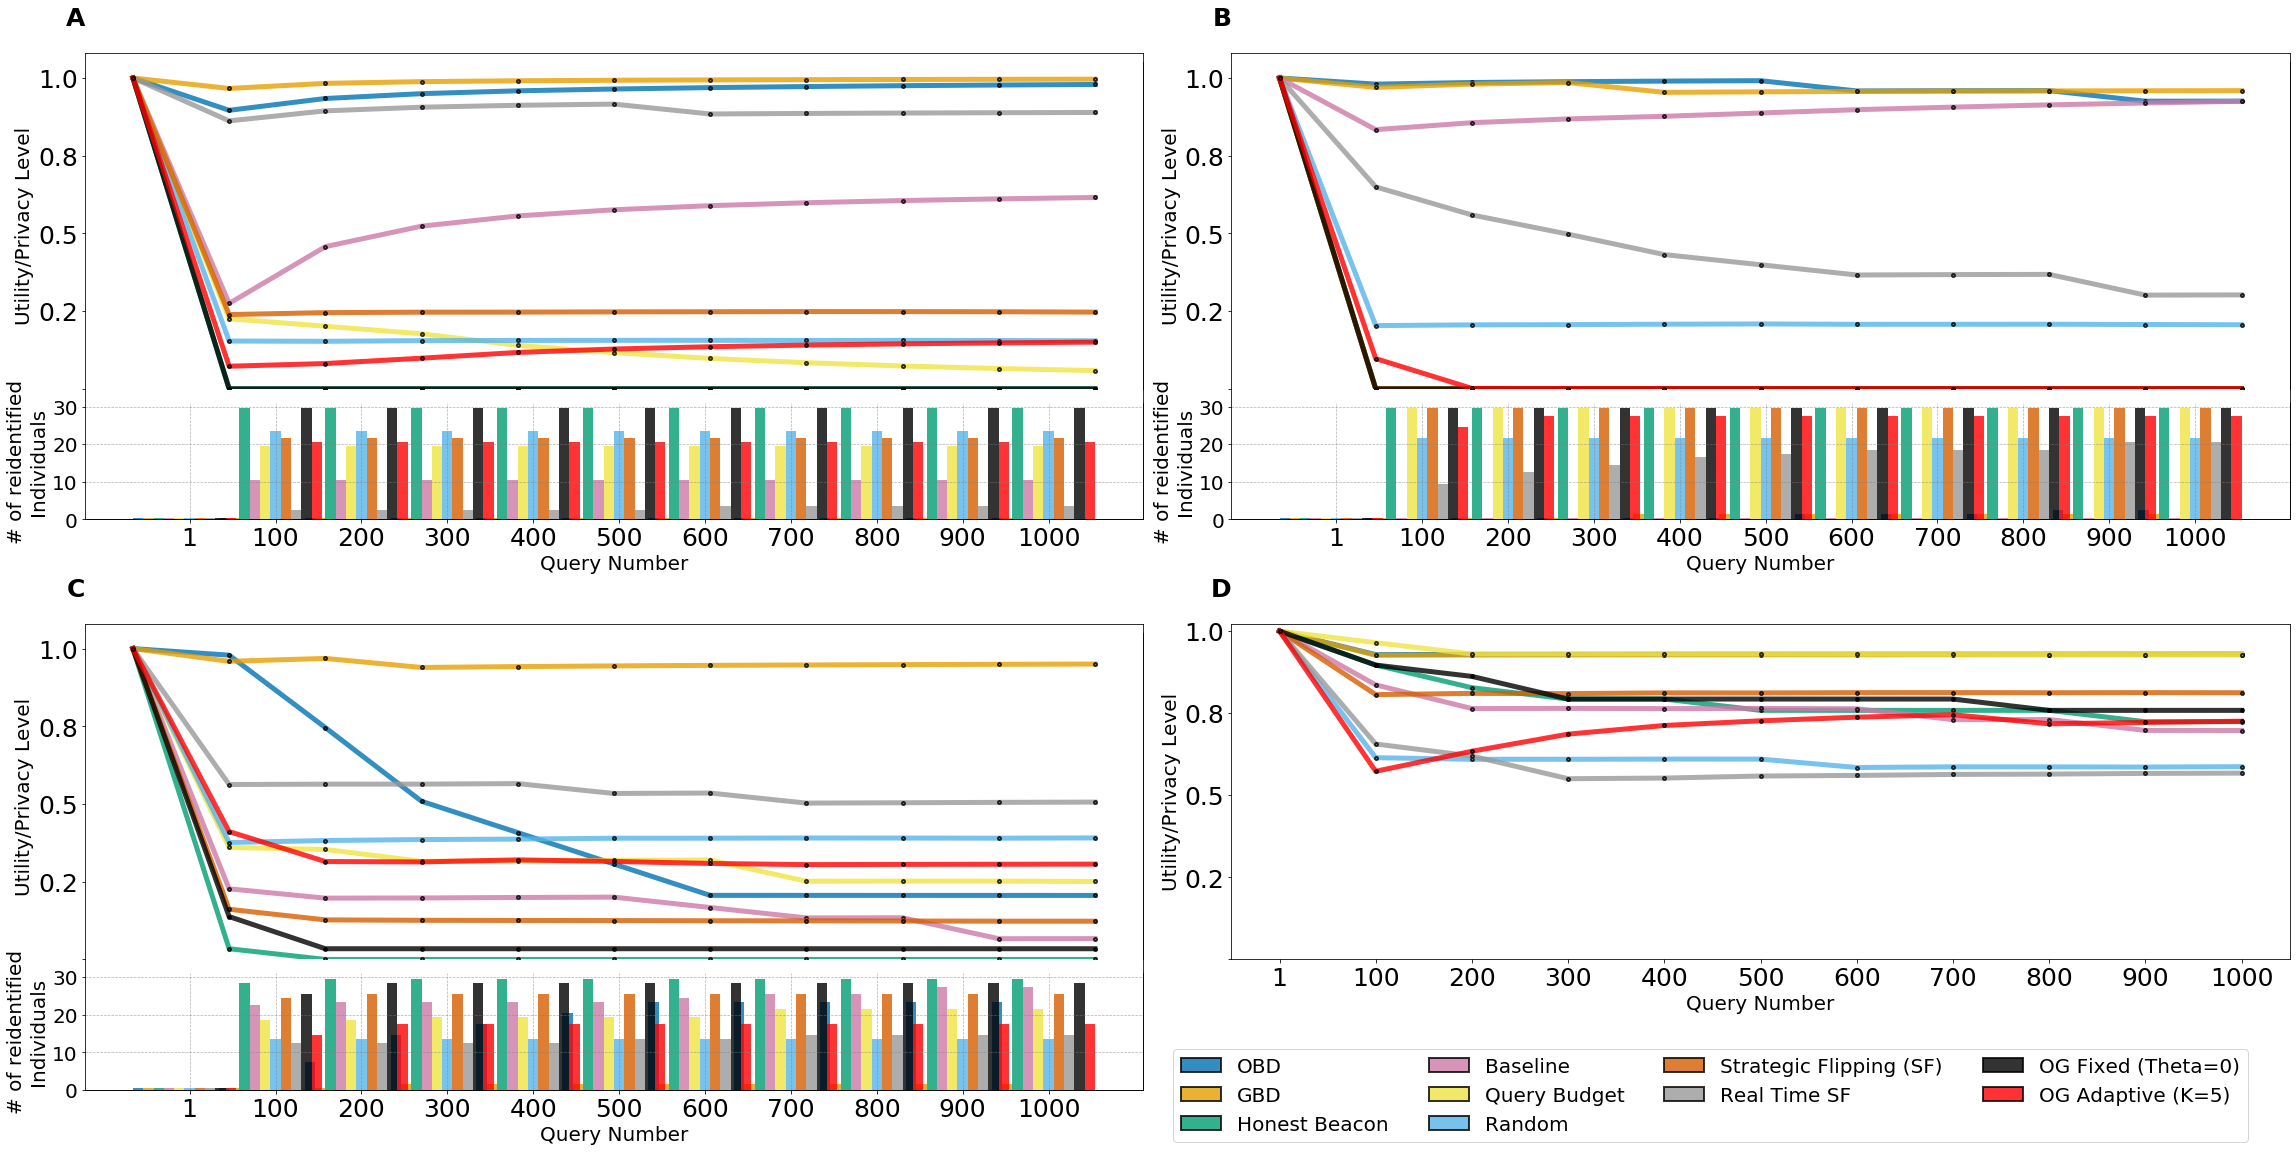

In [24]:
line_and_bar_plot3(np.array(line_data_list), np.array(bar_data_list), labels, ylabel_line="Utility/Privacy Level", ylabel_bar="# of reidentified\nIndividuals")